# Project - 4 Node Classification Using Graph Neural Network In Pytorch Geometric

In [2]:
# Importing & installing required libraries
import os
import torch
os.environ["TORCH"] = torch.__version__
print(torch.__version__)

!pip install -q torch-scatter -f https://data.pyg.org/whl/torch-${TORCH}.html
!pip install -q torch-sparse -f https://data.pyg.org/whl/torch-${TORCH}.html
!pip install -q git+https://github.com/pyg-team/pytorch_geometric.git

2.11.0+cu128
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 111.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 42.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [3]:
# Helper functions for visualizations
%matplotlib inline
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import networkx as nx

In [25]:
# TSNE visualization function
def visualize(h, color):
  z = TSNE(n_components=2).fit_transform(h.detach().cpu().numpy())

  plt.figure(figsize=(10, 10))
  plt.xticks([])
  plt.yticks([])

  plt.scatter(z[:, 0], z[:, 1], s=70, c=color, cmap="Set2")
  plt.show()

In [9]:
# Importing & loading the dataset
from torch_geometric.datasets import Planetoid
from torch_geometric.transforms import NormalizeFeatures

dataset = Planetoid(root="data/Planetoid", name="Cora", transform=NormalizeFeatures(), force_reload=False)
# Add 'force_reload=False' only when the dataset files are downloaded in the the mentioned folder, otherwise remove this argument.
print()
print(f"Dataset: {dataset}")
print("==========================")
print(f"Number of graphs: {len(dataset)}")
print(f"Number of features: {dataset.num_features}")
print(f"Number of classes: {dataset.num_classes}")


Dataset: Cora()
Number of graphs: 1
Number of features: 1433
Number of classes: 7


In [8]:
# Getting one graph object
data = dataset[0]
print("Data: ", data)
print("\n=================================\n")

# Gathering some information about the graph
print(f"Number of nodes: {data.num_nodes}")
print(f"Number of edges: {data.num_edges}")
print(f"Number of training nodes: {data.train_mask.sum()}")
print(f"Training node label rate: {int(data.train_mask.sum()) / data.num_nodes:.2f}")
print(f"Has isolated nodes: {data.has_isolated_nodes()}")
print(f"Has self-loops: {data.has_self_loops()}")
print(f"Is directed: {data.is_directed()}")
data.train_mask # Out 2708 node values 140 values are True which means they are the training nodes.

Data:  Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])


Number of nodes: 2708
Number of edges: 10556
Number of training nodes: 140
Training node label rate: 0.05
Has isolated nodes: False
Has self-loops: False
Is directed: False


tensor([ True,  True,  True,  ..., False, False, False])

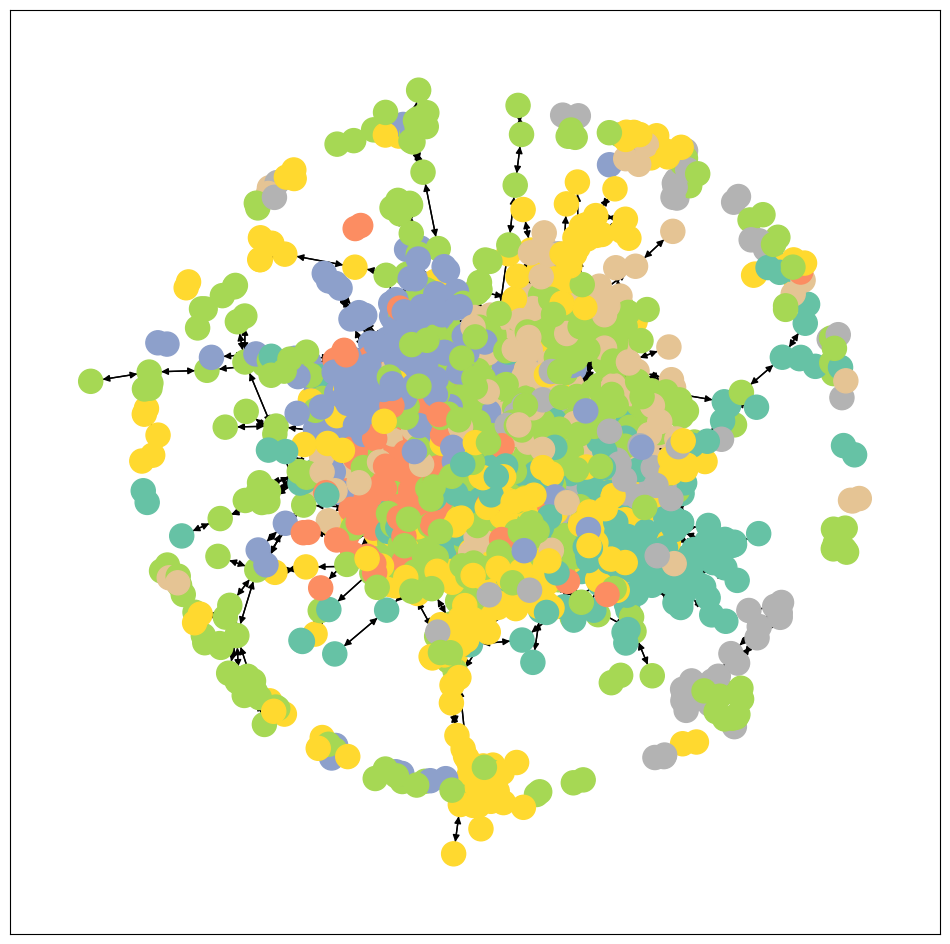

In [10]:
# Visualizing using networkx
from torch_geometric.utils import to_networkx

def visualize_nx(G, color):
  plt.figure(figsize=(12, 12))
  plt.xticks([])
  plt.yticks([])
  nx.draw_networkx(G, pos=nx.spring_layout(G, seed=42), with_labels=False, node_color=color, cmap="Set2")
  plt.show()

karate_undirected_graph = to_networkx(data)
visualize_nx(karate_undirected_graph, color=data.y)

# Training A Multi-Layer Perception Network (MLP)


Lets verify that by constructing simple MLP that solely operates on input node features (using shared weights across all nodes).

In [13]:
import torch
from torch.nn import Linear
import torch.nn.functional as F

class MLP(torch.nn.Module):
  def __init__(self, hidden_channels):
    super().__init__()
    torch.manual_seed(12345)
    self.lin1 = Linear(dataset.num_features, hidden_channels)
    self.lin2 = Linear(hidden_channels, dataset.num_classes)

  def forward(self, x):
    x = self.lin1(x)
    x = x.relu()
    x = F.dropout(x, p=0.5, training=self.training)
    x = self.lin2(x)
    return x

model = MLP(hidden_channels=16)
print(model)

MLP(
  (lin1): Linear(in_features=1433, out_features=16, bias=True)
  (lin2): Linear(in_features=16, out_features=7, bias=True)
)


Training Method For MLP

In [14]:
# Restricting height of output cell
from IPython.display import Javascript
display(Javascript('''google.colab.output.setIframeHeight(0, true, {maxHeight: 300})'''))

model = MLP(hidden_channels=16)
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

def train():
  model.train()
  optimizer.zero_grad() # Clearing gradients
  out = model(data.x) # Perform  single forward pass
  loss = criterion(out[data.train_mask], data.y[data.train_mask]) # Computing the loss solely based on the training nodes.
  loss.backward() # Deriving gradients
  optimizer.step()
  return loss

def test():
  model.eval()
  out = model(data.x)
  pred = out.argmax(dim=1) # Using the class with highest probability
  test_correct = pred[data.test_mask] == data.y[data.test_mask] # Check against ground-truth labels.
  test_acc = int(test_correct.sum()) / int(data.test_mask.sum()) # Deriving ratio of correct predictions.
  return test_acc

for epoch in range(1, 201):
  loss = train()
  print(f"Epoch: {epoch:03d}, Loss: {loss:.4f}") # '03d' is used to format the output to integer 'd' of minimum '3' digits padding with 0s at begining if needed.


<IPython.core.display.Javascript object>

Epoch: 001, Loss: 1.9609
Epoch: 002, Loss: 1.9558
Epoch: 003, Loss: 1.9485
Epoch: 004, Loss: 1.9413
Epoch: 005, Loss: 1.9297
Epoch: 006, Loss: 1.9266
Epoch: 007, Loss: 1.9124
Epoch: 008, Loss: 1.9024
Epoch: 009, Loss: 1.8985
Epoch: 010, Loss: 1.8849
Epoch: 011, Loss: 1.8753
Epoch: 012, Loss: 1.8684
Epoch: 013, Loss: 1.8483
Epoch: 014, Loss: 1.8465
Epoch: 015, Loss: 1.8115
Epoch: 016, Loss: 1.8143
Epoch: 017, Loss: 1.7900
Epoch: 018, Loss: 1.7985
Epoch: 019, Loss: 1.7639
Epoch: 020, Loss: 1.7383
Epoch: 021, Loss: 1.7229
Epoch: 022, Loss: 1.7452
Epoch: 023, Loss: 1.7000
Epoch: 024, Loss: 1.6855
Epoch: 025, Loss: 1.6691
Epoch: 026, Loss: 1.6479
Epoch: 027, Loss: 1.6284
Epoch: 028, Loss: 1.5960
Epoch: 029, Loss: 1.5562
Epoch: 030, Loss: 1.5396
Epoch: 031, Loss: 1.5488
Epoch: 032, Loss: 1.5224
Epoch: 033, Loss: 1.4665
Epoch: 034, Loss: 1.4885
Epoch: 035, Loss: 1.4399
Epoch: 036, Loss: 1.4035
Epoch: 037, Loss: 1.4265
Epoch: 038, Loss: 1.3742
Epoch: 039, Loss: 1.3742
Epoch: 040, Loss: 1.3391


Accuracy

In [20]:
# Finding accuracy
test_acc = test()
print(f"Test Accuracy: {test_acc * 100:.2f}%")

Test Accuracy: 57.40%


# Training A Graph Neural Network (GNN)

In [21]:
from torch_geometric.nn import GCNConv

class GCN(torch.nn.Module):
  def __init__(self, hidden_channels):
    super().__init__()
    torch.manual_seed(1234567)
    self.conv1 = GCNConv(dataset.num_features, hidden_channels)
    self.conv2 = GCNConv(hidden_channels, dataset.num_classes)

  def forward(self, x, edge_index):
    x = self.conv1(x, edge_index)
    x = x.relu()
    x = F.dropout(x, p=0.5, training=self.training)
    x = self.conv2(x, edge_index)
    return x

model = GCN(hidden_channels=16)
print(model)

GCN(
  (conv1): GCNConv(1433, 16)
  (conv2): GCNConv(16, 7)
)


Visualizing The Model Before Training

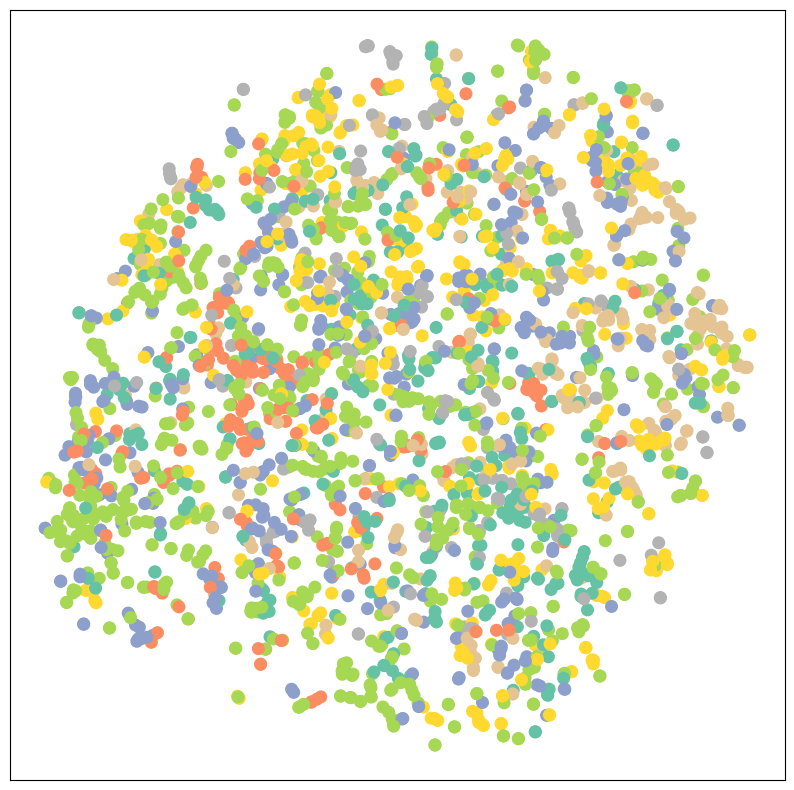

In [26]:
# Visualizing the model using TSNE
model = GCN(hidden_channels=16)
model.eval()

out = model(data.x, data.edge_index)
visualize(out, color=data.y)

Training Method For GNN

In [38]:
# Restricting height of output cell
from IPython.display import Javascript
display(Javascript('''google.colab.output.setIframeHeight(0, true, {maxHeight: 300})'''))

model = GCN(hidden_channels=16)
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

def train():
  model.train()
  optimizer.zero_grad() # Clearing gradients
  out = model(data.x, data.edge_index) # Perform  single forward pass
  loss = criterion(out[data.train_mask], data.y[data.train_mask]) # Computing the loss solely based on the training nodes.
  loss.backward() # Deriving gradients
  optimizer.step()
  return loss

def test():
  model.eval()
  out = model(data.x, data.edge_index)
  pred = out.argmax(dim=1) # Using the class with highest probability
  test_correct = pred[data.test_mask] == data.y[data.test_mask] # Check against ground-truth labels.
  test_acc = int(test_correct.sum()) / int(data.test_mask.sum()) # Deriving ratio of correct predictions.
  return test_acc

for epoch in range(1, 201):
  loss = train()
  print(f"Epoch: {epoch:03d}, Loss: {loss:.4f}") # '03d' is used to format the output to integer 'd' of minimum '3' digits padding with 0s at begining if needed.


<IPython.core.display.Javascript object>

Epoch: 001, Loss: 1.9465
Epoch: 002, Loss: 1.9419
Epoch: 003, Loss: 1.9363
Epoch: 004, Loss: 1.9290
Epoch: 005, Loss: 1.9199
Epoch: 006, Loss: 1.9140
Epoch: 007, Loss: 1.9079
Epoch: 008, Loss: 1.8992
Epoch: 009, Loss: 1.8876
Epoch: 010, Loss: 1.8764
Epoch: 011, Loss: 1.8656
Epoch: 012, Loss: 1.8626
Epoch: 013, Loss: 1.8460
Epoch: 014, Loss: 1.8329
Epoch: 015, Loss: 1.8225
Epoch: 016, Loss: 1.8167
Epoch: 017, Loss: 1.7995
Epoch: 018, Loss: 1.7878
Epoch: 019, Loss: 1.7716
Epoch: 020, Loss: 1.7568
Epoch: 021, Loss: 1.7563
Epoch: 022, Loss: 1.7342
Epoch: 023, Loss: 1.7092
Epoch: 024, Loss: 1.7015
Epoch: 025, Loss: 1.6671
Epoch: 026, Loss: 1.6757
Epoch: 027, Loss: 1.6609
Epoch: 028, Loss: 1.6355
Epoch: 029, Loss: 1.6339
Epoch: 030, Loss: 1.6102
Epoch: 031, Loss: 1.5964
Epoch: 032, Loss: 1.5721
Epoch: 033, Loss: 1.5570
Epoch: 034, Loss: 1.5445
Epoch: 035, Loss: 1.5093
Epoch: 036, Loss: 1.4889
Epoch: 037, Loss: 1.4776
Epoch: 038, Loss: 1.4704
Epoch: 039, Loss: 1.4263
Epoch: 040, Loss: 1.3972


Accuracy

In [39]:
# Finding accuracy
test_acc = test()
print(f"Test Accuracy: {test_acc * 100:.2f} %")

Test Accuracy: 81.40 %


Visualizing The Model After Training

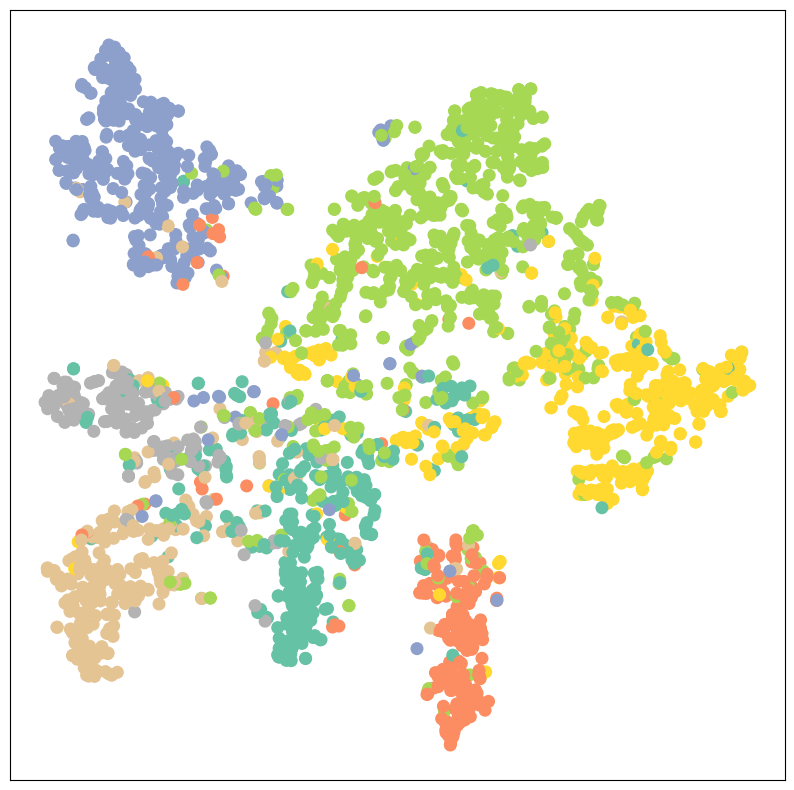

In [40]:
model.eval()

out = model(data.x, data.edge_index)
visualize(out, color=data.y)

# GNN Explainer

This method produces a node mask and a feature mask that reveals nodes/features that were important in producing such a prediction.

In [61]:
from torch_geometric.explain import Explainer, GNNExplainer

x, edge_index = data.x, data.edge_index

explainer = Explainer(
    model=model,
    algorithm=GNNExplainer(epochs=200),
    explanation_type='model',
    node_mask_type='attributes',
    edge_mask_type='object',
    model_config=dict(
        mode='multiclass_classification',
        task_level='node',
        return_type='raw',
    ),
)

node_idx = 1

explanation = explainer(x, edge_index, index=node_idx)
# Attempt to access node_mask as node_feat_mask is not available
node_feat_mask = explanation.node_mask
edge_mask = explanation.edge_mask

GNN Explainer Visualization

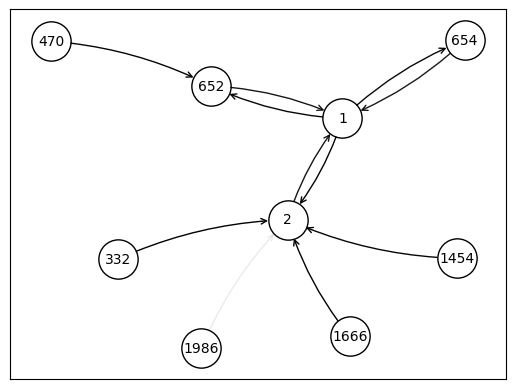

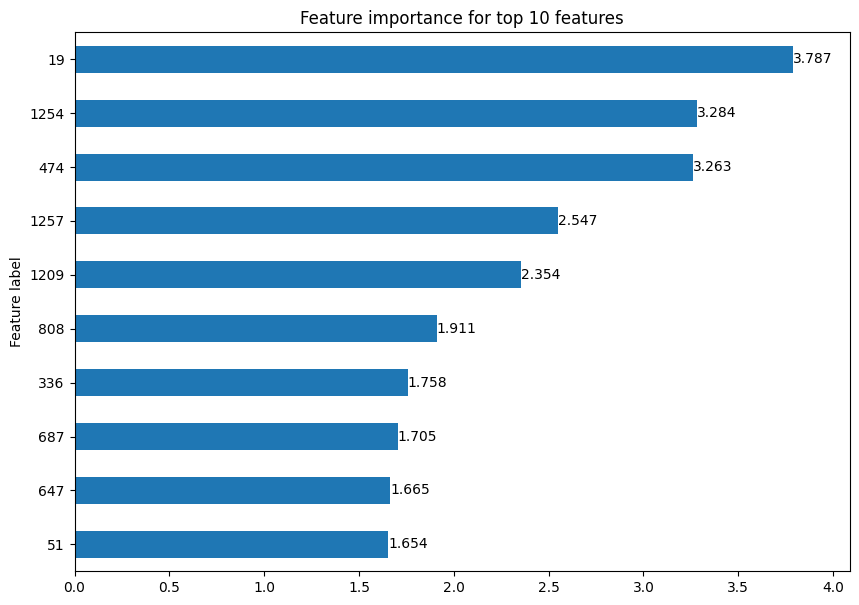

In [62]:
# Built-in subgraph visualization (uses edge_mask to weight edges)
explanation.visualize_graph(backend='networkx')
plt.show()

# Feature importance plot (bar chart of node_mask summed over the subgraph)
explanation.visualize_feature_importance(top_k=10)
plt.show()